In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [2]:
liver_dataset = pd.read_csv('liver_cirrhosis.csv')
liver_dataset.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [3]:
liver_dataset.shape

(25000, 19)

In [4]:
print(liver_dataset.columns.tolist())

['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [5]:
liver_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

In [9]:
liver_dataset.duplicated().sum()

np.int64(15361)

In [11]:
liver_dataset.drop_duplicates(inplace=True)

In [12]:
liver_dataset.duplicated().sum()

np.int64(0)

Encoding

In [13]:
categorical_columns = liver_dataset.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object')


In [14]:
from sklearn.preprocessing import LabelEncoder
encoders = {}

for col in liver_dataset.select_dtypes(include='object').columns:
    le = LabelEncoder()
    liver_dataset[col] = le.fit_transform(liver_dataset[col])
    encoders[col] = le

In [15]:
liver_dataset.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,0,1,18499,0,0,1,0,0,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,0,1,19724,1,1,0,1,0,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,0,1,11839,0,0,0,0,0,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,2,1,16467,0,0,0,0,0,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,2,1,21699,0,0,1,0,0,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


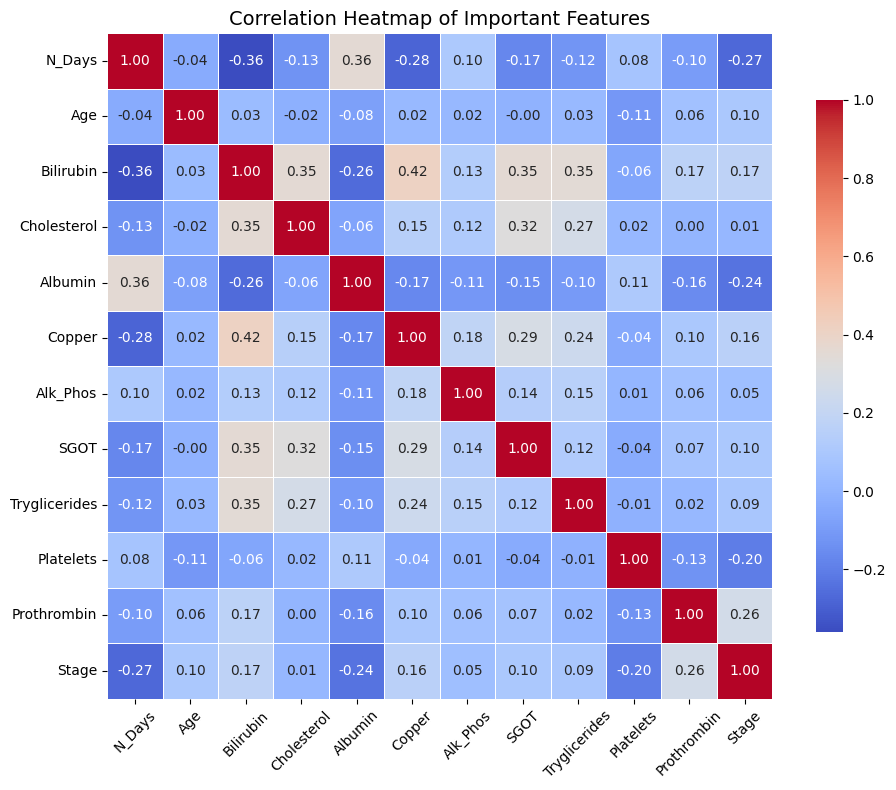

In [16]:
important_cols = [
    'N_Days',
    'Age',
    'Bilirubin',
    'Cholesterol',
    'Albumin',
    'Copper',
    'Alk_Phos',
    'SGOT',
    'Tryglicerides',
    'Platelets',
    'Prothrombin',
    'Stage'
]
corr_matrix = liver_dataset[important_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Important Features', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

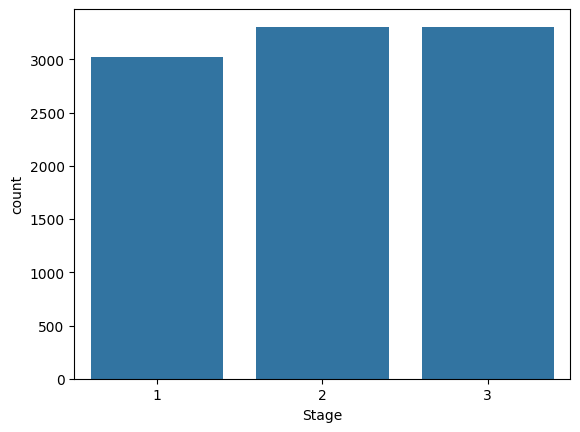

In [17]:
sns.countplot(x='Stage', data=liver_dataset)
plt.show()

Model Building

In [22]:
input_data = liver_dataset.drop('Stage', axis=1)
output_data = liver_dataset['Stage']

In [23]:
input_data.shape

(9639, 18)

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    input_data,
    output_data,
    test_size = 0.2,
    random_state = 42,
)

In [25]:
print(x_train.shape)
print(x_test.shape)

(7711, 18)
(1928, 18)


Model Training

In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(x_test)
y_pred

array([3, 2, 1, ..., 1, 1, 2], shape=(1928,))

In [28]:
x_train.head(1)

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
209,3445,2,1,20684,0,0,1,0,0,2.0,267.0,3.67,89.0,754.0,196.85,90.0,269.0,9.7


In [29]:
print( liver_dataset.columns.tolist())

['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [32]:
sample_patient = pd.DataFrame([{
    'N_Days': 1000,
    'Status': 0,
    'Drug': 1,
    'Age': 25000,
    'Sex': 0,
    'Ascites': 0,
    'Hepatomegaly': 0,
    'Spiders': 0,
    'Edema': 0,
    'Bilirubin': 4.5,
    'Cholesterol': 250,
    'Albumin': 3.3,
    'Copper': 150,
    'Alk_Phos': 1500,
    'SGOT': 195,
    'Tryglicerides': 120,
    'Platelets': 200,
    'Prothrombin': 12.0
}])

prediction = model.predict(sample_patient)

print("Predicted Liver Cirrhosis Stage:", prediction[0])

Predicted Liver Cirrhosis Stage: 3


In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8729253112033195


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.87      0.85      0.86       617
           2       0.83      0.85      0.84       640
           3       0.91      0.91      0.91       671

    accuracy                           0.87      1928
   macro avg       0.87      0.87      0.87      1928
weighted avg       0.87      0.87      0.87      1928



In [35]:
joblib.dump(model, "cirrhosis_model.pkl")

['cirrhosis_model.pkl']